#### <font color=navy><b>This Jupyter notebook demonstrates Langchain Basic Prompt engineering by interfacing with AWS Bedrock Models

## Runnables

#### A Runnable is a unit of work that can be invoked, batched, streamed, transformed, and composed into larger workflows.
    
    It enables building complex pipelines using LCEL by chaining multiple Runnables together.

<font color=red><b> Examples: prompt, prompt_templates, llm instance, tool call, output_parsers etc are runnables

### LangChain Expression Language (LCEL)

    - The LangChain Expression Language (LCEL) uses a declarative style to build new Runnables from existing ones, enabling runtime optimization.
    
<font color=red><b> **Chains** created with LCEL are just Runnables that fully implement the Runnable interface.



**Chain in LangChain** is a sequence of commands that the LLMs execute.
    
    Chain is an end-to-end wrapper around multiple individual components.
    
    It consists of a ‘PromptTemplate’, a model (either an LLM or a Chat Model), and an optional output parser.


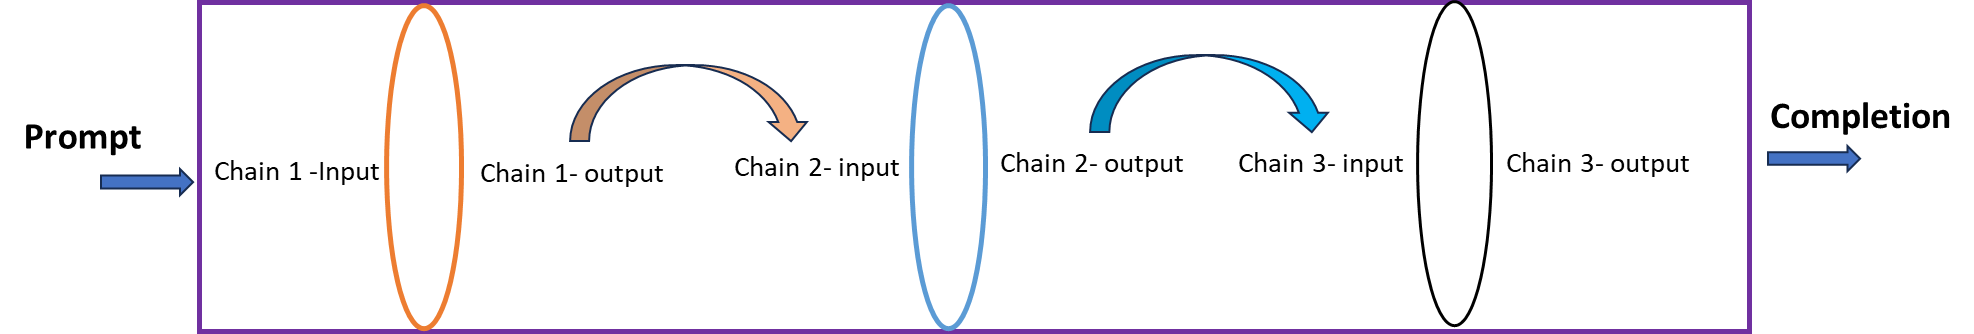

In [4]:
# get a token: https://huggingface.co/docs/api-inference/quicktour#get-your-api-token
import getpass
import os

<font color=Red><b> Create an LLM instance

In [5]:
from langchain_aws import ChatBedrockConverse
llm=ChatBedrockConverse(model='cohere.command-r-plus-v1:0', #amazon.nova-lite-v1:0
                       aws_access_key_id='',
                       aws_secret_access_key='',
                       region_name='us-east-1',max_tokens=200)
llm.invoke("Hi")


AIMessage(content='Hello! How can I help you today?', additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': '1728881b-ba8d-49d3-a211-aa386cf7aa4b', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 20 Mar 2026 08:35:20 GMT', 'content-type': 'application/json', 'content-length': '232', 'connection': 'keep-alive', 'x-amzn-requestid': '1728881b-ba8d-49d3-a211-aa386cf7aa4b'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [416]}, 'model_provider': 'bedrock_converse', 'model_name': 'cohere.command-r-plus-v1:0'}, id='lc_run--019d0a62-7ba0-7c73-8002-586947888c19-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1, 'output_tokens': 9, 'total_tokens': 10, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

<font color=Red><b> Create a prompt Template

In [6]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate


prompt = ChatPromptTemplate.from_messages(
    [("user", "Create a small  jingle on {adjective} in 10 words.")],
)

prompt

ChatPromptTemplate(input_variables=['adjective'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['adjective'], input_types={}, partial_variables={}, template='Create a small  jingle on {adjective} in 10 words.'), additional_kwargs={})])

<font color=Red><b> Create a chain which takes two runnables "prompt" and "model"

##### <font color=blue><b> LangChain supports various types of chains. This section covers the legacy LLMChain (LangChain V1) implemented using LCEL ( LangChain V3) and the StuffDocumentsChain, which are commonly used for building LLM-powered workflows.

## 1.LCEL chain

    In LangChain Expression Language two or more runnables can be "chained" together into sequences. The output of the previous runnable's .invoke() call is passed as input to the next runnable. This can be done using the pipe operator (|)

In [7]:
#!pip  show langchain langgraph

In [8]:
chain = prompt | llm

chain.invoke({"adjective": "Indian Cinema"})

AIMessage(content="Lights, camera, action! India's cinema, a vibrant, colorful dream!", additional_kwargs={}, response_metadata={'ResponseMetadata': {'RequestId': 'd0240f5a-052d-47fb-8742-02b697b85c32', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Fri, 20 Mar 2026 08:35:24 GMT', 'content-type': 'application/json', 'content-length': '268', 'connection': 'keep-alive', 'x-amzn-requestid': 'd0240f5a-052d-47fb-8742-02b697b85c32'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [568]}, 'model_provider': 'bedrock_converse', 'model_name': 'cohere.command-r-plus-v1:0'}, id='lc_run--019d0a62-8cd3-7663-9abc-d3a667e87f00-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 16, 'total_tokens': 30, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}})

<font color=Red><b> Create a chain which takes two runnables "prompt" , "model" , and "StringOutputParser"

In [9]:
chain = prompt | llm | StrOutputParser()
chain.invoke({"adjective": "Indian Cinema"})

"Lights, camera, action! India's cinema, a vibrant dream factory!"

#### <font color=Navy><b> Asking Multiple Questions

<font color= Blue><b>

1.   Place all questions into a single prompt for the LLM; this will only work for more advanced LLMs.
2.   Iterate through all questions using the generate method, answering them one at a time.



In [10]:
prompt = ChatPromptTemplate.from_messages(
    [("user", "respond to the following queries {qs}")],
)
 
chain = prompt | llm | StrOutputParser()

In [11]:
chain

ChatPromptTemplate(input_variables=['qs'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['qs'], input_types={}, partial_variables={}, template='respond to the following queries {qs}'), additional_kwargs={})])
| ChatBedrockConverse(profile={'max_input_tokens': 128000, 'max_output_tokens': 4096, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True}, client=<botocore.client.BedrockRuntime object at 0x72fe30748b80>, bedrock_client=<botocore.client.Bedrock object at 0x72fe309a3c70>, model_id='cohere.command-r-plus-v1:0', max_tokens=200, region_name='us-east-1', aws_access_key_id=SecretStr(''), aws_secret_access_key=SecretStr(''), provider='cohere', supports_tool_choice_values=())
| StrOutputP

In [12]:
qs = [
    {'question': "Which NFL team won the Super Bowl in the 2010 season?"},
    {'question': "Who is the first Nobel prize winner?"},
    {'question': "Who was the 12th person on the moon?"},
    {'question': "where is Taj Mahal Located?"}
]
res = chain.invoke(qs)
print(res)

Here are the answers to your queries: 

- The Green Bay Packers won the Super Bowl for the 2010 NFL season, defeating the Pittsburgh Steelers 31-25 at Cowboys Stadium.

- The first Nobel Prize winner was a man named Jean Henri Dunant, who received the Nobel Peace Prize in 1901. He was a Swiss humanitarian and the founder of the Red Cross. 

- There were only 11 astronauts who walked on the moon, so there wasn't a 12th person. However, the last man to walk on the moon, and the 11th person, was Eugene Cernan, who was part of the Apollo 17 mission in 1972. 

- The Taj Mahal is located in Agra, India. It is a stunning white marble mausoleum built by Mughal emperor Shah Jahan in memory of his beloved wife, Mumtaz Mahal, who died during childbirth. Construction began in


In [13]:
qs = [
    {'question': "Which NFL team won the Super Bowl in the 2010 season?"},
    {'question': "Who is the first Nobel prize winner?"},
    {'question': "Who was the 12th person on the moon?"},
    {'question': "where is Taj Mahal Located?"}
]
res = chain.invoke(qs)
print(res)

Here are the answers to your queries: 

- The Green Bay Packers won the Super Bowl for the 2010 NFL season, defeating the Pittsburgh Steelers 31-25 at Cowboys Stadium.

- The first Nobel Prize winner was a man named Jean Henri Dunant, who received the Nobel Peace Prize in 1901. He was a Swiss humanitarian and the founder of the Red Cross. 

- There were only 11 astronauts who walked on the moon, so there wasn't a 12th person. However, the last man to walk on the moon, and the 11th person, was Eugene Cernan, who was part of the Apollo 17 mission in 1972. 

- The Taj Mahal is located in Agra, India. It is a stunning white marble mausoleum built by Mughal emperor Shah Jahan in memory of his beloved wife, Mumtaz Mahal, who died during childbirth. Construction began in


## from_template 

    Use this when you have a single template string (system, human, or other role) with placeholders.

    Most common for simple prompts.

In [14]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template(
    "Summarize this content: {context}"
)

print(prompt.format(context="The cat sat on the mat."))
# -> Summarize this content: The cat sat on the mat.


Human: Summarize this content: The cat sat on the mat.


## from_messages

    Use this when you want to create a chat-style prompt with multiple roles/messages (system, human, AI, etc.).

    Each message can have its own template, and placeholders can be filled dynamically.

In [15]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "Please summarize the following content: {context}")
])

print(prompt.format(context="The cat sat on the mat."))
# -> system: You are a helpful assistant.
# -> human: Please summarize the following content: The cat sat on the mat.


System: You are a helpful assistant.
Human: Please summarize the following content: The cat sat on the mat.


## 2. Stuff Documents Chain
    StuffDocumentsChain combines documents by simply concatenating them into a single context window, making it a simple yet effective method for tasks like question answering, summarization, and more.

In [16]:
from langchain_core.documents import Document

documents = [
    Document(page_content="The stock market saw a significant rise today.", metadata={"source": "CNN", "category": "Finance"}),
    Document(page_content="A new species of frog was discovered in the Amazon.", metadata={"source": "NatGeo", "category": "Science"}),
]


In [18]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("Summarize this content: {context}")
chain = create_stuff_documents_chain(llm, prompt)

2026-03-16 06:00:37.292985: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/labuser/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [19]:
chain

RunnableBinding(bound=RunnableBinding(bound=RunnableAssign(mapper={
  context: RunnableLambda(format_docs)
}), kwargs={}, config={'run_name': 'format_inputs'}, config_factories=[])
| ChatPromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='Summarize this content: {context}'), additional_kwargs={})])
| ChatBedrockConverse(profile={'max_input_tokens': 128000, 'max_output_tokens': 4096, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True}, client=<botocore.client.BedrockRuntime object at 0x72fe30748b80>, bedrock_client=<botocore.client.Bedrock object at 0x72fe309a3c70>, model_id='cohere.command

In [20]:
result = chain.invoke({"context": documents})
result

'The stock market experienced a notable surge, while a new species of frog was found in the vast Amazon rainforest. These two seemingly unrelated events highlight the diverse nature of global developments, showcasing the interplay between financial markets and scientific discoveries in our ever-changing world.'

In [21]:
for chunk in chain.stream({"context": documents}):
    print(chunk, end=" | ")

 | The |  stock |  market |  experienced |  a |  notable |  surge | , |  while |  a |  new |  species |  of |  frog |  was |  found |  in |  the |  vast |  Amazon |  rainforest | . |  These |  two |  seemingly |  unrelated |  events |  highlight |  the |  diverse |  nature |  of |  global |  developments | , |  showcasing |  the |  interplay |  between |  financial |  markets |  and |  scientific |  discoveries |  in |  our |  ever | - | changing |  world | . |  |  |  |  | 